# Daten mit Python untersuchen
Bevor wir eine eigene KI entwickeln, machen wir uns zunächst damit vertraut, wie man mit Python Daten untersuchen kann. 

In [161]:
import pandas as pd
liederdaten = pd.read_csv("Musikdaten/songs.csv")
testdaten = liederdaten.iloc[1400:]
liederdaten = liederdaten.iloc[:1400]
liederdaten

,artist,song,duration_ms,year,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,2000,77,0.751,0.834,-5.444,0.0437,0.30000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,1999,79,0.434,0.897,-4.918,0.0488,0.01030,0.000000,0.6120,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,1999,66,0.529,0.496,-9.007,0.0290,0.17300,0.000000,0.2510,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,2000,78,0.551,0.913,-4.063,0.0466,0.02630,0.000013,0.3470,0.544,119.992,"rock, metal"
4,*NSYNC,Bye Bye Bye,200560,2000,65,0.614,0.928,-4.806,0.0516,0.04080,0.001040,0.0845,0.879,172.656,pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1395,Shawn Mendes,Señorita,190799,2019,78,0.759,0.548,-6.049,0.0290,0.03920,0.000000,0.0828,0.749,116.967,pop
1396,Post Malone,Sunflower - Spider-Man: Into the Spider-Verse,157560,2019,79,0.755,0.522,-4.368,0.0575,0.53300,0.000000,0.0685,0.925,89.960,hip hop
1397,Regard,Ride It,157605,2019,81,0.880,0.751,-4.258,0.0874,0.17700,0.000064,0.1060,0.884,117.948,"pop, Dance/Electronic"
1398,Lady Gaga,Shallow,215733,2018,82,0.572,0.385,-6.362,0.0308,0.37100,0.000000,0.2310,0.323,95.799,pop


In [183]:
spalten = ['loudness', 'energy']
liederdaten = liederdaten[['song', 'artist', 'popularity'] + spalten]
testdaten = testdaten[['song', 'artist', 'popularity'] + spalten]
liederdaten

,song,artist,popularity,loudness,energy
0,Oops!...I Did It Again,Britney Spears,0.895349,0.744639,0.825230
1,All The Small Things,blink-182,0.918605,0.770630,0.891961
2,Breathe,Faith Hill,0.767442,0.568584,0.467217
3,It's My Life,Bon Jovi,0.906977,0.812877,0.908908
4,Bye Bye Bye,*NSYNC,0.755814,0.776164,0.924796
...,...,...,...,...,...
1395,Señorita,Shawn Mendes,0.906977,0.714745,0.522296
1396,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,0.918605,0.797806,0.494757
1397,Ride It,Regard,0.941860,0.803241,0.737316
1398,Shallow,Lady Gaga,0.953488,0.699279,0.349645


In [184]:
# Min-Max-Normalisierung der gewünschten Spalten
liederdaten[spalten] = (liederdaten[spalten] - liederdaten[spalten].min()) / (liederdaten[spalten].max() - liederdaten[spalten].min())
liederdaten

,song,artist,popularity,loudness,energy
0,Oops!...I Did It Again,Britney Spears,0.895349,0.744639,0.825230
1,All The Small Things,blink-182,0.918605,0.770630,0.891961
2,Breathe,Faith Hill,0.767442,0.568584,0.467217
3,It's My Life,Bon Jovi,0.906977,0.812877,0.908908
4,Bye Bye Bye,*NSYNC,0.755814,0.776164,0.924796
...,...,...,...,...,...
1395,Señorita,Shawn Mendes,0.906977,0.714745,0.522296
1396,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,0.918605,0.797806,0.494757
1397,Ride It,Regard,0.941860,0.803241,0.737316
1398,Shallow,Lady Gaga,0.953488,0.699279,0.349645


In [185]:
from sklearn.neighbors import NearestNeighbors
model = NearestNeighbors(n_neighbors=5)
model.fit(liederdaten[spalten])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


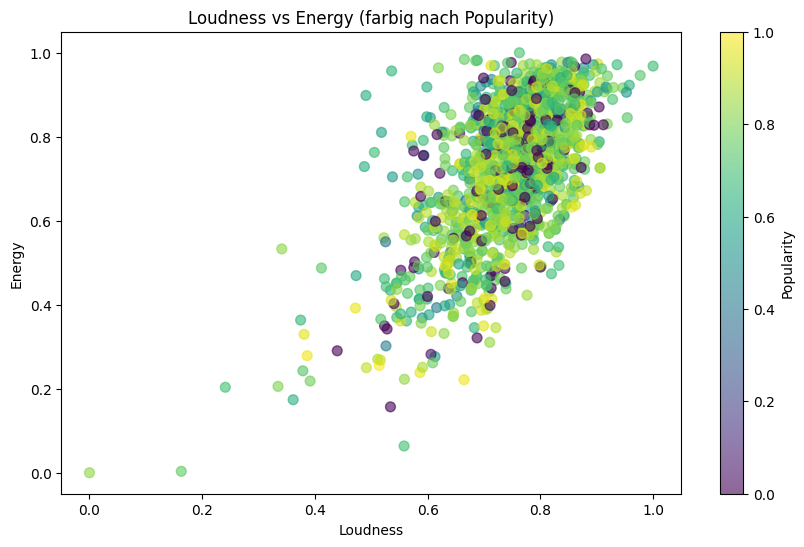

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(liederdaten['loudness'], liederdaten['energy'], c=liederdaten['popularity'], cmap='viridis', s=50, alpha=0.6)
plt.xlabel('Loudness')
plt.ylabel('Energy')
plt.title('Loudness vs Energy (farbig nach Popularity)')
plt.colorbar(scatter, label='Popularity')
plt.show()

In [186]:
model.kneighbors(testdaten[spalten])[1]

array([[1128,  371,  411,  140,  446],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  140,  446],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  140,  446],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  446,  140],
       [1128,  371,  411,  140,  446],
       [1128,  371,  411,

In [164]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(liederdaten[spalten], liederdaten['popularity'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [172]:
neuesLied = pd.DataFrame({
    'tempo': [0.36],
    'danceability': [0.27],
    'valence': [0.12],
    'energy': [0.255]
})
model.predict(testdaten[spalten])

array([8.4000000e+01, 6.0000000e+01, 7.9000000e+01, 8.2000000e+01,
       1.0000000e+00, 7.5000000e+01, 6.3000000e+01, 2.6359912e-16,
       8.6000000e+01, 7.7000000e+01, 7.6000000e+01, 7.2000000e+01,
       7.2000000e+01, 7.1000000e+01, 7.7000000e+01, 7.6000000e+01,
       6.5000000e+01, 7.0000000e+00, 7.9000000e+01, 7.3000000e+01,
       7.8000000e+01, 4.0000000e+00, 7.4000000e+01, 7.0000000e+01,
       7.0000000e+01, 6.9000000e+01, 7.5000000e+01, 3.5000000e+01,
       7.1000000e+01, 1.0000000e+00, 7.1000000e+01, 5.7000000e+01,
       7.8000000e+01, 6.4000000e+01, 7.5000000e+01, 6.9000000e+01,
       2.0000000e+00, 8.0000000e+01, 7.3000000e+01, 7.3000000e+01,
       7.1000000e+01, 6.3000000e+01, 7.9000000e+01, 7.8000000e+01,
       6.9000000e+01, 7.5000000e+01, 8.5000000e+01])

In [130]:
trainingsdaten = liederdaten[['artist', 'song', 'popularity', 'energy', 'tempo', 'danceability']]
testdaten = trainingsdaten.iloc[1000:]
trainingsdaten = trainingsdaten.iloc[0:1000]
trainingsdaten

,artist,song,popularity,energy,tempo,danceability
0,Britney Spears,Oops!...I Did It Again,0.895349,0.825230,0.232272,0.744910
1,blink-182,All The Small Things,0.918605,0.891961,0.588118,0.365269
2,Faith Hill,Breathe,0.767442,0.467217,0.509441,0.479042
3,Bon Jovi,It's My Life,0.906977,0.908908,0.397615,0.505389
4,*NSYNC,Bye Bye Bye,0.755814,0.924796,0.746771,0.580838
...,...,...,...,...,...,...
995,Justin Bieber,Beauty And A Beat,0.848837,0.834763,0.450727,0.566467
996,Pitbull,Don't Stop the Party (feat. TJR),0.744186,0.956572,0.444130,0.710180
997,Selena Gomez,Come & Get It,0.802326,0.775448,0.132333,0.499401
998,Disclosure,White Noise,0.627907,0.835822,0.397522,0.641916


In [131]:
# Min-Max-Normalisierung der gewünschten Spalten
cols = ['popularity', 'energy', 'tempo', 'danceability']
trainingsdaten[cols] = (trainingsdaten[cols] - trainingsdaten[cols].min()) / (trainingsdaten[cols].max() - trainingsdaten[cols].min())
trainingsdaten

,artist,song,popularity,energy,tempo,danceability
0,Britney Spears,Oops!...I Did It Again,0.905882,0.824636,0.232272,0.744910
1,blink-182,All The Small Things,0.929412,0.891593,0.588118,0.365269
2,Faith Hill,Breathe,0.776471,0.465405,0.509441,0.479042
3,Bon Jovi,It's My Life,0.917647,0.908598,0.397615,0.505389
4,*NSYNC,Bye Bye Bye,0.764706,0.924540,0.746771,0.580838
...,...,...,...,...,...,...
995,Justin Bieber,Beauty And A Beat,0.858824,0.834201,0.450727,0.566467
996,Pitbull,Don't Stop the Party (feat. TJR),0.752941,0.956425,0.444130,0.710180
997,Selena Gomez,Come & Get It,0.811765,0.774684,0.132333,0.499401
998,Disclosure,White Noise,0.635294,0.835264,0.397522,0.641916


In [132]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5)
model.fit(trainingsdaten[['energy', 'tempo', 'danceability']], trainingsdaten['popularity'])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [133]:
model.predict(testdaten[['energy', 'tempo']])

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- danceability


In [ ]:
neuesLied = pd.DataFrame({
    'energy': [0.9],
    'tempo': [150]
})
vorhersage = model.predict(neuesLied)
print("Die vorhergesagte Popularität des neuen Liedes beträgt:", vorhersage[0])

AttributeError: 'NearestNeighbors' object has no attribute 'predict'